#### 🏠 House Price Prediction using Multiple Linear Regression
#### 📌 Project Overview

This project implements Multiple Linear Regression to predict house prices based on various property features such as area, number of bedrooms, bathrooms, stories, mainroad, and additional amenities. The project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature encoding, model training, prediction, and performance evaluation using Scikit-learn.

#### 🎯 Problem Statement

The objective of this project is to develop a machine learning model that accurately predicts the selling price of a house using multiple property characteristics. Since house prices depend on several factors rather than a single variable, Multiple Linear Regression is used to model the relationship between the target variable and multiple independent features.

#### 📚 What is Multiple Linear Regression?

Multiple Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value based on two or more independent variables. It models the relationship between multiple input features and a single target variable by fitting the best possible regression equation.

The mathematical equation is:

Price = β₀ + β₁X₁ + β₂X₂ + β₃X₃ + ... + βₙXₙ

where,

- β₀ = Intercept
- β₁, β₂, ..., βₙ = Coefficients
- X₁, X₂, ..., Xₙ = Independent Variables
- Price = Target Variable

#### 📦 Import Libraries

The following Python libraries are used throughout this project for data manipulation, visualization, machine learning, and model evaluation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#### 📥 Load Dataset

The dataset is loaded into a Pandas DataFrame for further exploration and preprocessing.

In [3]:
df = pd.read_csv('housing.csv')

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#### 📂 Dataset Understanding

The dataset contains information about residential properties, including both numerical and categorical features.

The target variable is **price**, while the remaining columns describe different characteristics of each house.

The dataset includes:

- Numerical Features
- Binary Categorical Features (Yes/No)
- Multi-class Categorical Features

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.shape

(545, 13)

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

#### 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure of the dataset before building the machine learning model.

In this section, we analyze:

- Distribution of numerical variables
- Relationship between variables
- Correlation among features
- Presence of missing values and duplicates

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

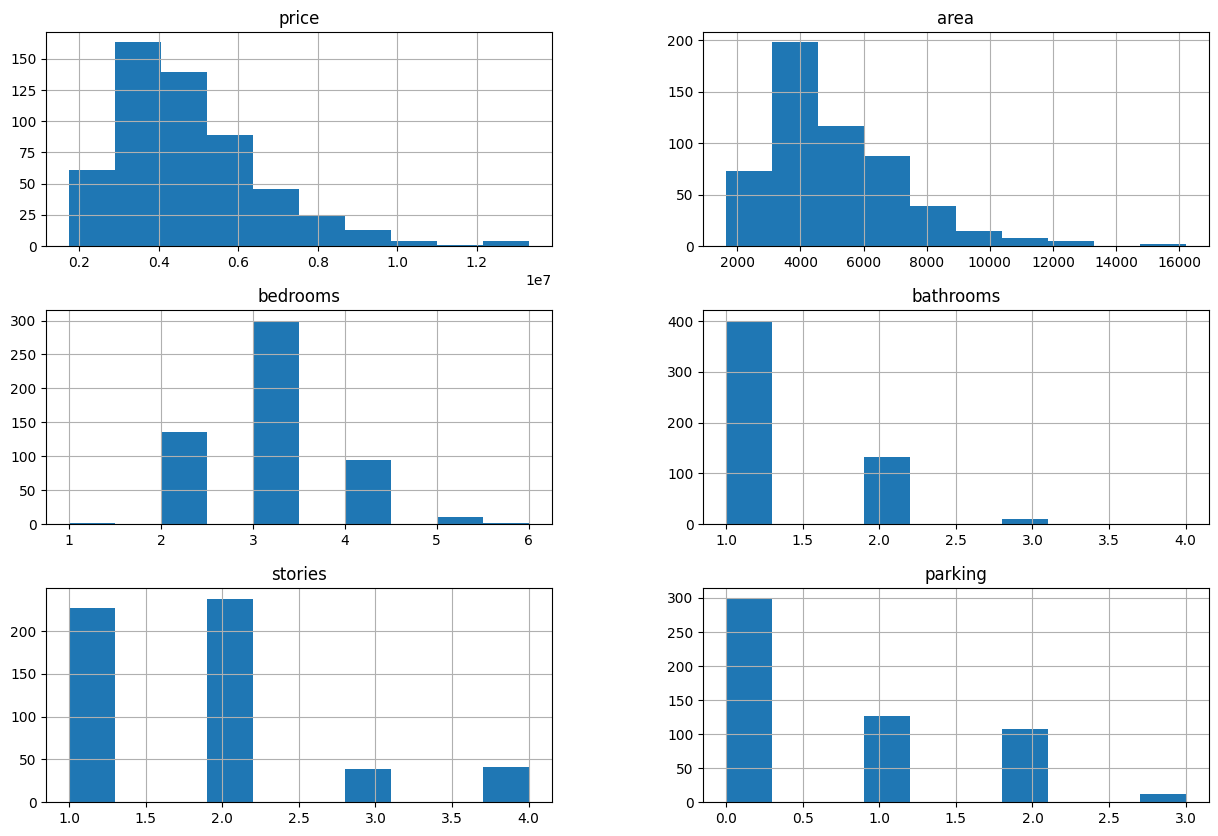

In [10]:
df.hist(figsize=(15,10))

<Axes: xlabel='price', ylabel='Count'>

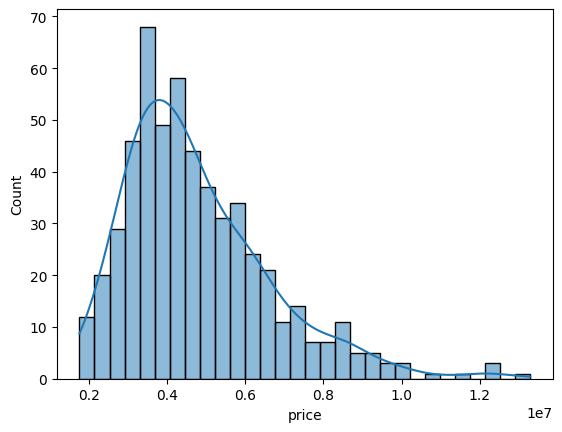

In [11]:
sns.histplot(df['price'],bins=30,kde=True)

<Axes: xlabel='area', ylabel='price'>

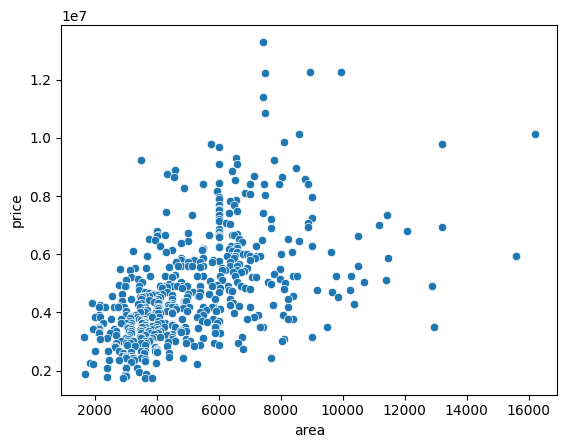

In [12]:
sns.scatterplot(x='area',y='price',data=df)

<Axes: xlabel='price'>

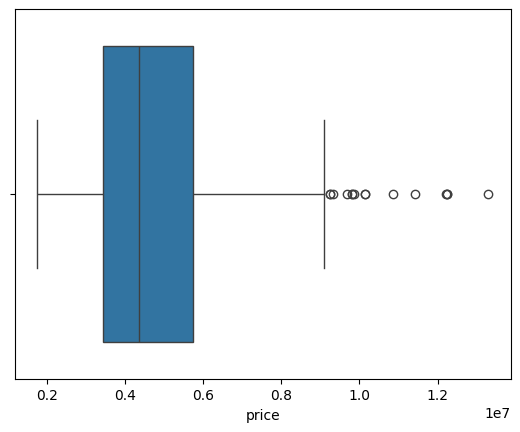

In [13]:
sns.boxplot(x=df['price'])

#### 🔥 Correlation Matrix

The correlation matrix measures the strength and direction of the linear relationship between numerical variables.

Correlation values range from **-1 to +1**.

- +1 → Perfect Positive Correlation
- 0 → No Correlation
- -1 → Perfect Negative Correlation

A higher positive correlation indicates that the variables increase together, whereas a negative correlation indicates an inverse relationship.

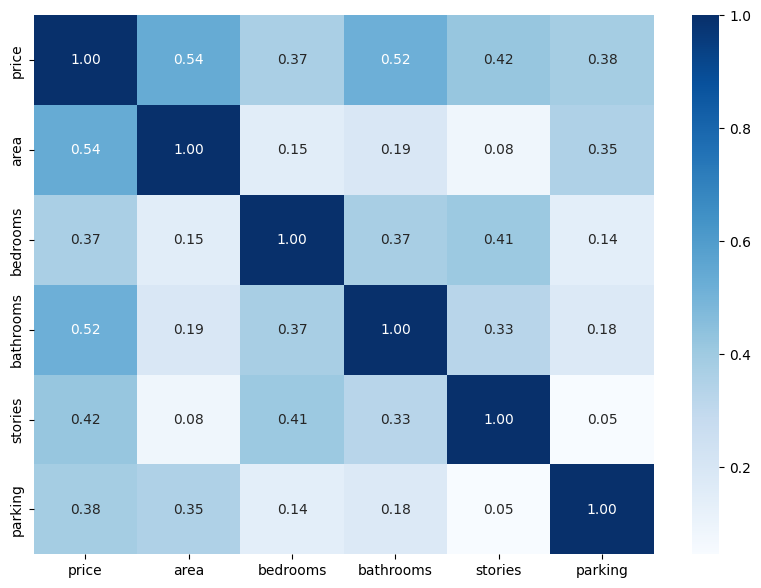

In [14]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='Blues')
plt.show()

#### 🔧 Data Preprocessing

Machine learning models cannot directly process categorical data represented as text.

Therefore, categorical variables such as "yes", "no", and furnishing status are converted into numerical values using encoding techniques.

In [15]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [16]:
binary_columns=['mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'prefarea']
for col in binary_columns:
    df[col] = df[col].map({
        'yes':1,
        'no':0
    })

In [17]:
df = pd.get_dummies(df,columns=['furnishingstatus'],drop_first=True)

In [18]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


#### 🎯 Feature Selection

The target variable is **price**, while all remaining columns are used as independent variables for training the Multiple Linear Regression model.

In [19]:
x = df.drop('price',axis=1)
y = df['price']

#### ✂️ Train-Test Split

Before training the machine learning model, the dataset is divided into two parts: the **training set** and the **testing set**.

- **Training Set:** Used to train the Multiple Linear Regression model by learning the relationship between the input features and the target variable.
- **Testing Set:** Used to evaluate the model's performance on unseen data and measure its ability to generalize.

In this project, **80% of the data** is used for training and **20%** is reserved for testing. Setting `random_state=42` ensures that the data split remains consistent every time the notebook is executed, making the results reproducible.

In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 📈 Model Coefficients

Each coefficient represents the expected change in house price when the corresponding feature increases by one unit while keeping all other features constant.

In [23]:
coef = pd.DataFrame({
    'Feature':x.columns,
    'Coefficient':model.coef_
})
coef

,Feature,Coefficient
0,area,2.359688e+02
1,bedrooms,7.677870e+04
2,bathrooms,1.094445e+06
3,stories,4.074766e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
6,basement,3.902512e+05
7,hotwaterheating,6.846499e+05
8,airconditioning,7.914267e+05
9,parking,2.248419e+05


#### 🏡 Predict House Price

After training the model, it can be used to estimate the price of a new house by providing values for all the input features.

The trained model applies the learned regression equation to these feature values and predicts the corresponding house price. This demonstrates how Multiple Linear Regression can be used to make predictions for new, unseen data.

In [24]:
new_house = pd.DataFrame({
    'area':[6500],
    'bedrooms':[3],
    'bathrooms':[2],
    'stories':[2],
    'mainroad':[1],
    'guestroom':[0],
    'basement':[1],
    'hotwaterheating':[0],
    'airconditioning':[1],
    'parking':[2],
    'prefarea':[1],
    'furnishingstatus_semi-furnished':[1],
    'furnishingstatus_unfurnished':[0]
})
prediction = model.predict(new_house)
print(prediction)

[7530298.88818599]


#### 📊 Model Evaluation

To assess the performance of the Multiple Linear Regression model, predictions are made on the testing dataset and compared with the actual house prices.

The following evaluation metrics are used:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted prices.
- **Mean Squared Error (MSE):** Calculates the average squared prediction error, giving more importance to larger errors.
- **Root Mean Squared Error (RMSE):** Represents the average prediction error in the same unit as the target variable.
- **R² Score (Coefficient of Determination):** Indicates how well the independent variables explain the variation in house prices. A value closer to **1** indicates better model performance.

In [27]:
y_pred = model.predict(x_test)
print('MAE: ',mean_absolute_error(y_test,y_pred))
print('MSE: ',mean_squared_error(y_test,y_pred))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2: ',r2_score(y_test,y_pred))

MAE:  970043.4039201634
MSE:  1754318687330.6628
RMSE:  1324506.9600914384
R2:  0.6529242642153186


In [29]:
print("Training R² :", model.score(x_train, y_train))
print("Testing R²  :", model.score(x_test, y_test))

Training R² : 0.6859438988560158
Testing R²  : 0.6529242642153186


#### 📋 Actual vs Predicted House Prices

A comparison between the actual house prices and the predicted values helps evaluate how accurately the model performs on unseen data.

If the predicted prices are close to the actual prices, the model has learned the underlying relationship effectively. Large differences between the two indicate prediction errors and suggest areas where the model can be improved.

In [31]:
comparison = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})
comparison.head(10)

,Actual,Predicted
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06
209,4900000,3.532275e+06
176,5250000,5.611775e+06
249,4543000,6.368146e+06
516,2450000,2.722857e+06
426,3353000,2.629406e+06


#### 📉 Residual Analysis

Residuals are the differences between the actual house prices and the predicted prices.

Residual analysis helps determine whether the model has captured the underlying pattern in the data effectively. Ideally, the residuals should be randomly distributed around zero without any visible pattern. A random distribution indicates that the assumptions of linear regression are reasonably satisfied and that the model has not introduced systematic errors.

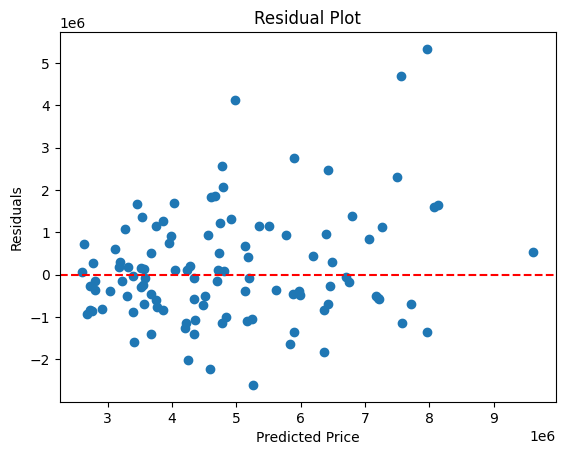

In [33]:
residuals = y_test - y_pred
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

#### Model Performance

The Multiple Linear Regression model achieved an **R² Score of approximately 0.65**, indicating that it explains about **65% of the variation** in house prices using the available features.

Although the model captures a significant portion of the relationship between house characteristics and price, there is still room for improvement. Factors such as property location, neighborhood quality, nearby amenities, and additional engineered features could further improve prediction accuracy.